# AFG raster sense check

Sense-checking rasters for Afghanistan monitoring.

Not relevant for this repo but just put here for quick check.

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [88]:
import os
from pathlib import Path

import xarray as xr
import rioxarray as rxr

from src.datasources import seas5

In [3]:
DATA_DIR = Path(os.getenv("AA_DATA_DIR_NEW"))

In [4]:
load_path = (
    DATA_DIR
    / "public"
    / "raw"
    / "glb"
    / "seas5"
    / "bfb42fc89f8b22dc387b995922460ef6.grib"
)

In [47]:
ds_cds = xr.open_dataset(load_path, engine="cfgrib")

In [80]:
ds_cds

<xarray.Dataset> Size: 3MB
Dimensions:     (time: 2, step: 6, latitude: 180, longitude: 360)
Coordinates:
    number      int64 8B ...
  * time        (time) datetime64[ns] 16B 2024-01-01 2025-01-01
  * step        (step) timedelta64[ns] 48B 90 days 91 days ... 151 days 152 days
    surface     float64 8B ...
  * latitude    (latitude) float64 1kB 89.5 88.5 87.5 86.5 ... -87.5 -88.5 -89.5
    valid_time  (time, step) datetime64[ns] 96B ...
  * longitude   (longitude) float64 3kB -179.5 -178.5 -177.5 ... 178.5 179.5
Data variables:
    tprate      (time, step, latitude, longitude) float32 3MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-01-21T15:29 GRIB to CDM+CF via cfgrib-0.9.1...

In [48]:
ds_cds = ds_cds.assign_coords(
    {"longitude": (ds_cds.coords["longitude"] - 180) % 360 - 180}
).sortby("longitude")

In [49]:
ds_cds.isel(time=0).mean(dim="step")

<xarray.Dataset> Size: 264kB
Dimensions:    (latitude: 180, longitude: 360)
Coordinates:
    number     int64 8B ...
    time       datetime64[ns] 8B 2024-01-01
    surface    float64 8B ...
  * latitude   (latitude) float64 1kB 89.5 88.5 87.5 86.5 ... -87.5 -88.5 -89.5
  * longitude  (longitude) float64 3kB -179.5 -178.5 -177.5 ... 178.5 179.5
Data variables:
    tprate     (latitude, longitude) float32 259kB 5.916e-09 ... 2.962e-09

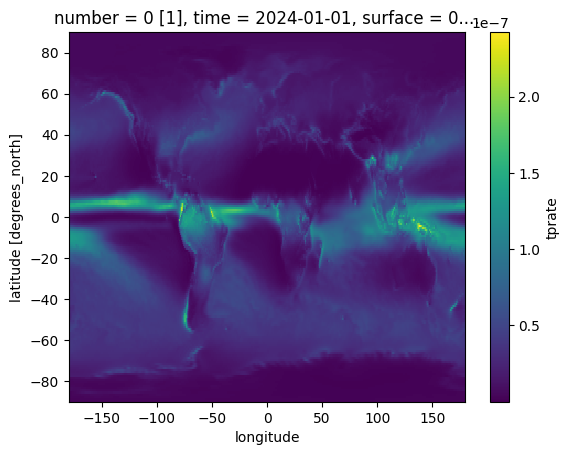

In [50]:
ds_cds.isel(time=0).mean(dim="step")["tprate"].plot()

In [51]:
ds_cds.isel(time=1).mean(dim="step")

<xarray.Dataset> Size: 264kB
Dimensions:    (latitude: 180, longitude: 360)
Coordinates:
    number     int64 8B ...
    time       datetime64[ns] 8B 2025-01-01
    surface    float64 8B ...
  * latitude   (latitude) float64 1kB 89.5 88.5 87.5 86.5 ... -87.5 -88.5 -89.5
  * longitude  (longitude) float64 3kB -179.5 -178.5 -177.5 ... 178.5 179.5
Data variables:
    tprate     (latitude, longitude) float32 259kB 5.852e-09 ... 3.259e-09

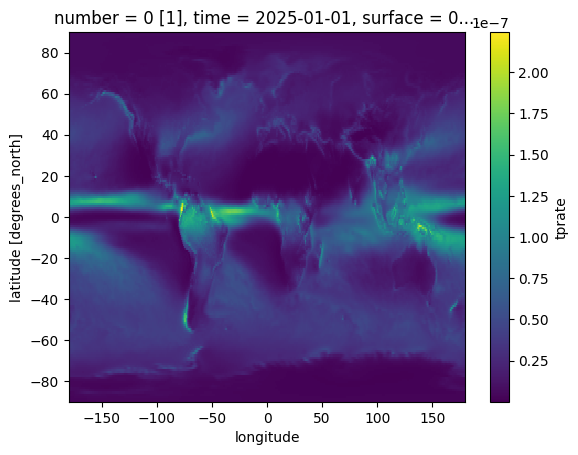

In [52]:
ds_cds.isel(time=1).mean(dim="step")["tprate"].plot()

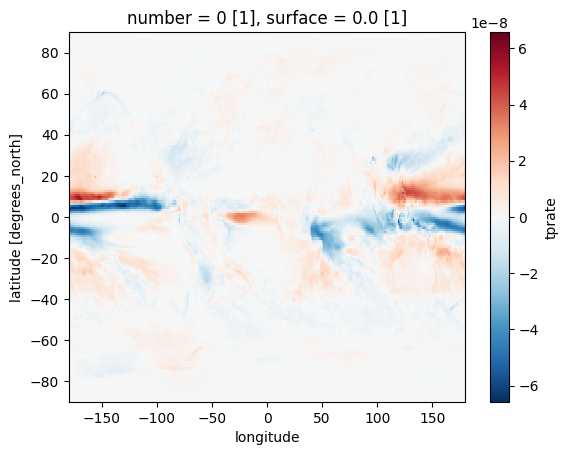

In [53]:
(ds_cds.isel(time=1).mean(dim="step") - ds_cds.isel(time=0).mean(dim="step"))[
    "tprate"
].plot()

In [70]:
das = []
for issued_date, stage in zip(["2024-01-01", "2025-01-01"], ["prod", "dev"]):
    das_lt = []
    for lt in [2, 3, 4]:
        print(issued_date, stage)
        da_in = seas5.load_seas5_raster(
            issued_date=issued_date, lt=lt, stage=stage
        )
        da_in["lt"] = lt
        das_lt.append(da_in)
    da_lt = xr.concat(das_lt, dim="lt")
    da_lt["issued_date"] = issued_date
    das.append(da_lt)

da = xr.concat(das, dim="issued_date")

2024-01-01 prod
2024-01-01 prod
2024-01-01 prod
2025-01-01 dev
2025-01-01 dev
2025-01-01 dev


In [71]:
da_lt

<xarray.DataArray (lt: 3, band: 1, y: 451, x: 900)> Size: 5MB
dask.array<concatenate, shape=(3, 1, 451, 900), dtype=float32, chunksize=(1, 1, 451, 900), chunktype=numpy.ndarray>
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 7kB -180.0 -179.6 -179.2 ... 178.8 179.2 179.6
  * y            (y) float64 4kB 90.0 89.6 89.2 88.8 ... -88.8 -89.2 -89.6 -90.0
    spatial_ref  int64 8B 0
  * lt           (lt) int64 24B 2 3 4
    issued_date  <U10 40B '2025-01-01'
Attributes: (12/19)
    averaging_period:  monthly
    date_issued:       None
    date_valid:        None
    download_date:     2025-01-21
    grid_resolution:   0.4
    leadtime:          2
    ...                ...
    year_issued:       2025
    year_valid:        2025
    AREA_OR_POINT:     Area
    scale_factor:      1.0
    add_offset:        0.0
    long_name:         total precipitation

In [72]:
da_tri = da.mean(dim="lt")

In [73]:
da_tri

<xarray.DataArray (issued_date: 2, band: 1, y: 451, x: 900)> Size: 3MB
dask.array<mean_agg-aggregate, shape=(2, 1, 451, 900), dtype=float32, chunksize=(1, 1, 451, 900), chunktype=numpy.ndarray>
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 7kB -180.0 -179.6 -179.2 ... 178.8 179.2 179.6
  * y            (y) float64 4kB 90.0 89.6 89.2 88.8 ... -88.8 -89.2 -89.6 -90.0
    spatial_ref  int64 8B 0
  * issued_date  (issued_date) <U10 80B '2024-01-01' '2025-01-01'

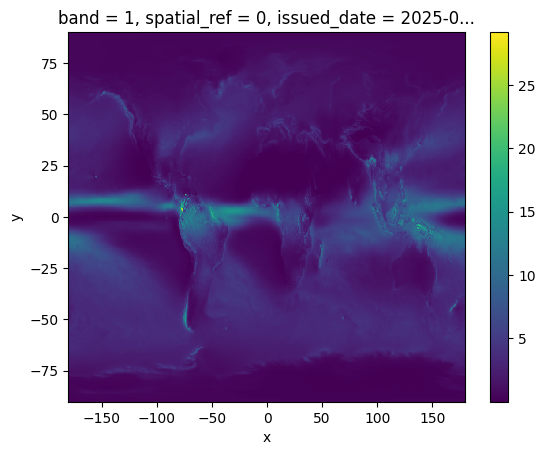

In [74]:
da_tri.isel(issued_date=1).plot()

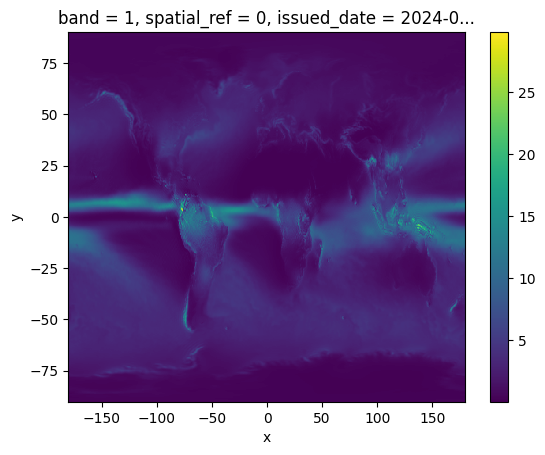

In [75]:
da_tri.isel(issued_date=0).plot()

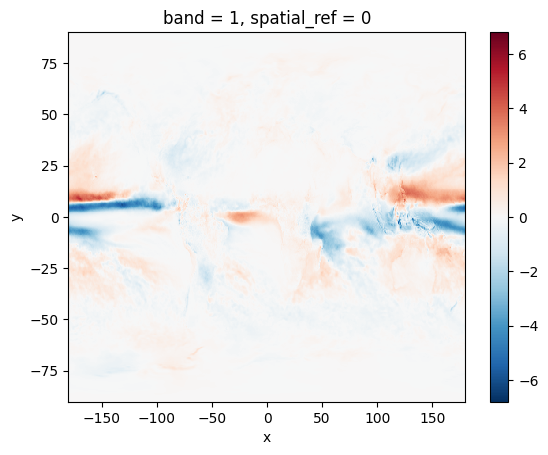

In [76]:
(da_tri.isel(issued_date=1) - da_tri.isel(issued_date=0)).plot()

In [79]:
save_dir = DATA_DIR / "public" / "processed" / "glb" / "seas5"

In [105]:
3600 * 24 * 1000

86400000

In [112]:
ds_cds

<xarray.Dataset> Size: 3MB
Dimensions:      (time: 2, step: 6, latitude: 180, longitude: 360)
Coordinates:
    number       int64 8B ...
  * time         (time) datetime64[ns] 16B 2024-01-01 2025-01-01
  * step         (step) timedelta64[ns] 48B 90 days 91 days ... 152 days
    surface      float64 8B ...
  * latitude     (latitude) float64 1kB 89.5 88.5 87.5 ... -87.5 -88.5 -89.5
    valid_time   (time, step) datetime64[ns] 96B ...
  * longitude    (longitude) float64 3kB -179.5 -178.5 -177.5 ... 178.5 179.5
    spatial_ref  int64 8B 0
Data variables:
    tprate       (time, step, latitude, longitude) float32 3MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-01-21T15:29 GRIB to CDM+CF via cfgrib-0.9.1...

In [109]:
for year_i in [0, 1]:
    filename = f"seas5_issued_jan_valid_mam_{2024+year_i}.tif"
    output_path = save_dir / filename
    ds_cds = ds_cds.rio.write_crs(4326)
    (
        ds_cds.isel(time=year_i).mean(dim="step")["tprate"] * 3600 * 24 * 1000
    ).rio.to_raster(output_path, driver="COG")

In [110]:
test = rxr.open_rasterio(output_path)

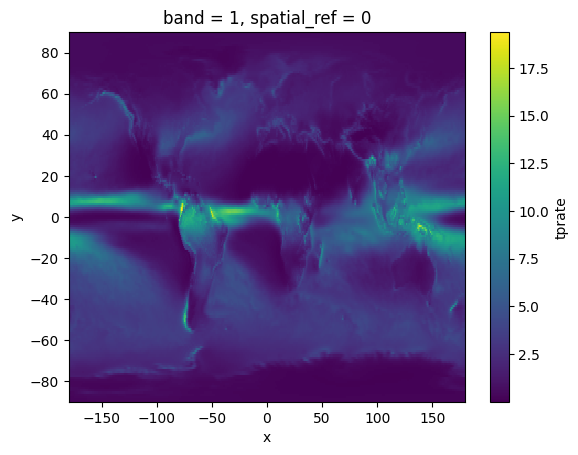

In [111]:
test.plot()

## RP calc

In [117]:
import pandas as pd

from src.utils import db_utils

In [143]:
query = f"SELECT * FROM public.polygon WHERE iso3 = 'AFG' AND adm_level = 1"
df_adm = pd.read_sql(query, engine)

In [144]:
df_adm

,pcode,iso3,adm_level,name,name_language,area,standard,imerg_n_intersect_raw_pixels,imerg_frac_raw_pixels,imerg_n_upsampled_pixels,era5_n_intersect_raw_pixels,era5_frac_raw_pixels,era5_n_upsampled_pixels,floodscan_n_intersect_raw_pixels,floodscan_frac_raw_pixels,floodscan_n_upsampled_pixels,seas5_n_intersect_raw_pixels,seas5_frac_raw_pixels,seas5_n_upsampled_pixels
0,AF34,AFG,1,Nimroz,EN,40397.5550,True,406,378.876530,1505,78,60.80,1520,None,None,None,37,23.781250,1522
1,AF15,AFG,1,Kunar,EN,4227.7230,True,52,40.782722,162,13,6.48,162,None,None,None,8,2.640625,169
2,AF28,AFG,1,Jawzjan,EN,10618.0550,True,121,106.991710,425,28,17.20,430,None,None,None,16,6.656250,426
3,AF12,AFG,1,Paktika,EN,18930.5590,True,197,179.997820,715,45,29.04,726,None,None,None,20,11.296875,723
4,AF31,AFG,1,Badghis,EN,19328.6430,True,206,189.815870,754,46,30.60,765,None,None,None,22,11.859375,759
5,AF29,AFG,1,Faryab,EN,20854.2620,True,233,207.941530,826,49,33.00,825,None,None,None,24,13.078125,837
6,AF17,AFG,1,Badakhshan,EN,43448.0550,True,490,439.798860,1747,101,69.56,1739,None,None,None,49,27.390625,1753
7,AF25,AFG,1,Uruzgan,EN,13160.4190,True,146,125.620860,499,30,20.08,502,None,None,None,18,8.000000,512
8,AF14,AFG,1,Khost,EN,4120.3555,True,49,39.523994,157,14,6.36,159,None,None,None,7,2.546875,163
9,AF11,AFG,1,Ghazni,EN,21601.0700,True,247,207.186300,823,48,33.36,834,None,None,None,25,13.000000,832


In [119]:
engine = db_utils.get_engine("prod")
query = f"SELECT * FROM public.seas5 WHERE iso3 = 'AFG' AND adm_level = 1"
df = pd.read_sql(query, engine, parse_dates=["valid_date", "issued_date"])

In [120]:
df

,iso3,pcode,valid_date,issued_date,leadtime,adm_level,mean,median,min,max,count,sum,std
0,AFG,AF34,1992-01-01,1992-01-01,0,1,0.384497,0.337078,0.134001,1.490965,1522,585.204600,0.215970
1,AFG,AF15,1992-01-01,1992-01-01,0,1,3.127160,2.711940,1.544273,4.649718,169,528.490100,1.117806
2,AFG,AF28,1992-01-01,1992-01-01,0,1,1.751289,1.646855,1.209886,2.482133,426,746.048900,0.341763
3,AFG,AF12,1992-01-01,1992-01-01,0,1,1.014228,1.023933,0.431676,1.382637,723,733.286900,0.242099
4,AFG,AF31,1992-01-01,1992-01-01,0,1,2.324812,2.305459,1.794574,2.767889,759,1764.532300,0.189343
...,...,...,...,...,...,...,...,...,...,...,...,...,...
125897,AFG,AF25,1992-06-01,1992-01-01,5,1,0.058018,0.048634,0.004579,0.428360,512,29.705170,0.057883
125898,AFG,AF14,1992-06-01,1992-01-01,5,1,1.413048,1.575910,0.426851,1.580562,163,230.326900,0.256194
125899,AFG,AF11,1992-06-01,1992-01-01,5,1,0.409650,0.381061,0.044938,0.903840,832,340.828580,0.248239
125900,AFG,AF26,1992-06-01,1992-01-01,5,1,0.052934,0.026783,0.005861,0.428360,647,34.248405,0.049736


In [126]:
df_jan_mam = (
    df[
        (df["valid_date"].dt.month.isin([3, 4, 5]))
        & (df["issued_date"].dt.month == 1)
    ]
    .groupby(["issued_date", "pcode"])["mean"]
    .mean()
    .reset_index()
)
df_jan_mam["year"] = df_jan_mam["issued_date"].dt.year

In [127]:
df_jan_mam

,issued_date,pcode,mean,year
0,1981-01-01,AF01,2.114793,1981
1,1981-01-01,AF02,2.065218,1981
2,1981-01-01,AF03,2.368771,1981
3,1981-01-01,AF04,1.640208,1981
4,1981-01-01,AF05,1.891404,1981
...,...,...,...,...
1525,2025-01-01,AF30,0.426938,2025
1526,2025-01-01,AF31,1.531002,2025
1527,2025-01-01,AF32,0.850792,2025
1528,2025-01-01,AF33,0.522200,2025


In [148]:
def calc_rp(group, col: str = "mean"):
    group["rank"] = group[col].rank(ascending=True)
    group["rp"] = (len(group) + 1) / group["rank"]
    return group

In [149]:
df_rp = (
    df_jan_mam.groupby("pcode")
    .apply(calc_rp, include_groups=False)
    .reset_index()
    .drop(columns="level_1")
)

In [150]:
df_rp

,pcode,issued_date,mean,year,rank,rp
0,AF01,1981-01-01,2.114793,1981,23.0,2.000000
1,AF01,1982-01-01,2.074432,1982,21.0,2.190476
2,AF01,1983-01-01,2.728698,1983,45.0,1.022222
3,AF01,1984-01-01,1.842633,1984,6.0,7.666667
4,AF01,1985-01-01,1.856616,1985,8.0,5.750000
...,...,...,...,...,...,...
1525,AF34,2021-01-01,0.079432,2021,4.0,11.500000
1526,AF34,2022-01-01,0.096812,2022,9.0,5.111111
1527,AF34,2023-01-01,0.184167,2023,45.0,1.022222
1528,AF34,2024-01-01,0.113473,2024,15.0,3.066667


In [151]:
df_rp = df_rp.merge(df_adm[["pcode", "name"]])

<Axes: xlabel='name'>

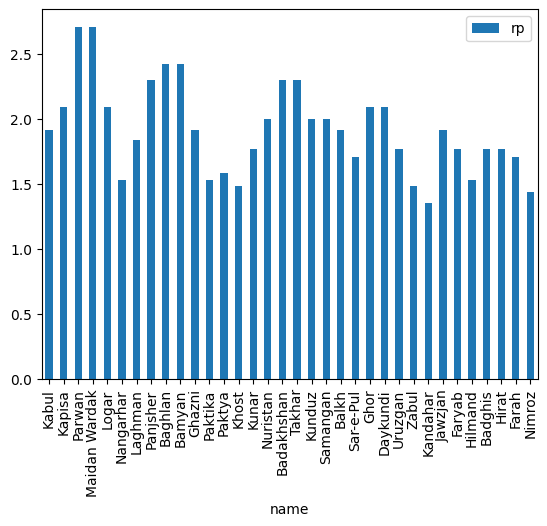

In [152]:
df_rp[df_rp["year"] == 2025].plot.bar(x="name", y="rp")

In [154]:
name_list = ["Badakhshan", "Takhar", "Sar-e-Pul", "Faryab"]

In [155]:
df_rp[df_rp["name"].isin(name_list) & (df_rp["year"] == 2025)]

,pcode,issued_date,mean,year,rank,rp,name
764,AF17,2025-01-01,2.755662,2025,20.0,2.300000,Badakhshan
809,AF18,2025-01-01,2.761372,2025,20.0,2.300000,Takhar
989,AF22,2025-01-01,2.100036,2025,27.0,1.703704,Sar-e-Pul
1304,AF29,2025-01-01,1.544600,2025,26.0,1.769231,Faryab


## Raster check

In [15]:
import matplotlib.pyplot as plt
import xarray as xr

from src.datasources import seas5
from src.utils import blob_utils

In [4]:
blob_utils.list_container_blobs(
    name_starts_with="seas5/monthly/processed/",
    stage="prod",
    container_name="raster",
)

['seas5/monthly/processed/precip_em_i1981-01-01_lt0.tif',
 'seas5/monthly/processed/precip_em_i1981-01-01_lt1.tif',
 'seas5/monthly/processed/precip_em_i1981-01-01_lt2.tif',
 'seas5/monthly/processed/precip_em_i1981-01-01_lt3.tif',
 'seas5/monthly/processed/precip_em_i1981-01-01_lt4.tif',
 'seas5/monthly/processed/precip_em_i1981-01-01_lt5.tif',
 'seas5/monthly/processed/precip_em_i1981-01-01_lt6.tif',
 'seas5/monthly/processed/precip_em_i1981-02-01_lt0.tif',
 'seas5/monthly/processed/precip_em_i1981-02-01_lt1.tif',
 'seas5/monthly/processed/precip_em_i1981-02-01_lt2.tif',
 'seas5/monthly/processed/precip_em_i1981-02-01_lt3.tif',
 'seas5/monthly/processed/precip_em_i1981-02-01_lt4.tif',
 'seas5/monthly/processed/precip_em_i1981-02-01_lt5.tif',
 'seas5/monthly/processed/precip_em_i1981-02-01_lt6.tif',
 'seas5/monthly/processed/precip_em_i1981-03-01_lt0.tif',
 'seas5/monthly/processed/precip_em_i1981-03-01_lt1.tif',
 'seas5/monthly/processed/precip_em_i1981-03-01_lt2.tif',
 'seas5/monthl

In [27]:
das = []
for issued_date in ["2025-01-01", "2024-01-01", "2023-01-01"]:
    da_in = seas5.load_seas5_raster(issued_date=issued_date, lt=0)
    da_in["issued_date"] = issued_date
    das.append(da_in)

da = xr.concat(das, dim="issued_date")

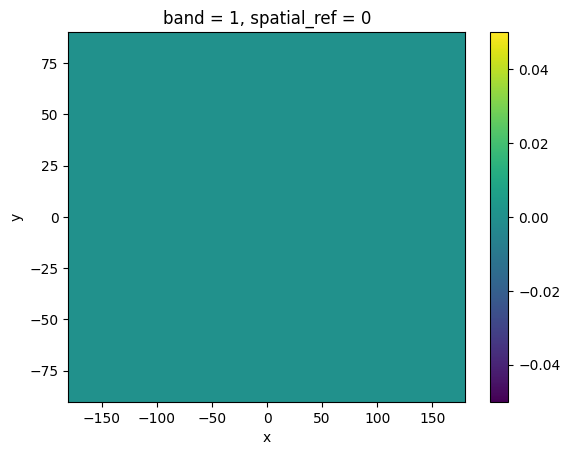

In [28]:
(da.isel(issued_date=0) - da.isel(issued_date=1)).plot()

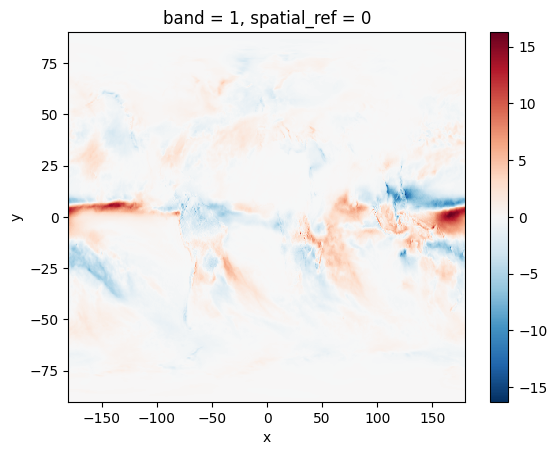

In [29]:
(da.isel(issued_date=1) - da.isel(issued_date=2)).plot()

In [34]:
das = []
for issued_date, stage in zip(["2025-01-01", "2024-01-01"], ["dev", "prod"]):
    da_in = seas5.load_seas5_raster(issued_date=issued_date, lt=0, stage="dev")
    da_in["issued_date"] = issued_date
    das.append(da_in)

da = xr.concat(das, dim="issued_date")

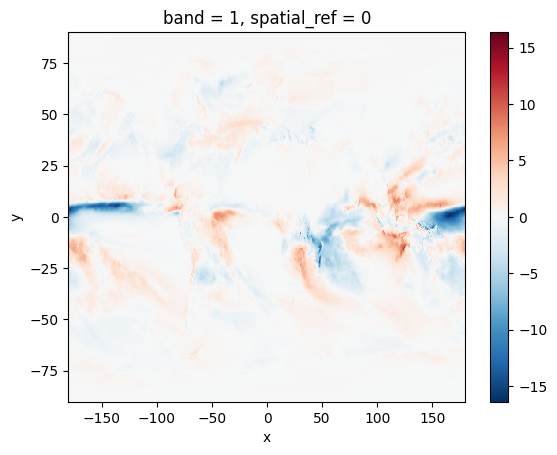

In [35]:
(da.isel(issued_date=0) - da.isel(issued_date=1)).plot()

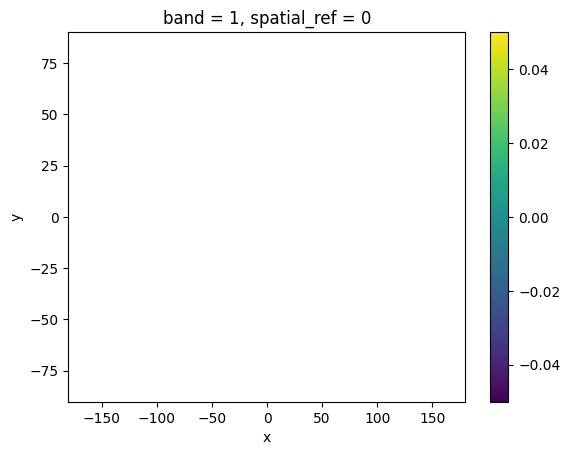

In [33]:
(da.isel(issued_date=1) - da.isel(issued_date=2)).plot()